<a href="https://colab.research.google.com/github/gollapudirevathi/Speech-Emotion-Recognition/blob/main/IDP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 pip install gradio

In [ ]:
!pip install keras-tuner


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


CNN+LSTM


Load_and_preprocess the dataset

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 58s 665ms/step - accuracy: 0.2300 - loss: 1.9448 - val_accuracy: 0.2487 - val_loss: 2.0393
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 79s 647ms/step - accuracy: 0.4587 - loss: 1.4437 - val_accuracy: 0.2609 - val_loss: 2.1982
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 82s 646ms/step - accuracy: 0.6047 - loss: 1.1155 - val_accuracy: 0.3363 - val_loss: 2.0681
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 48s 668ms/step - accuracy: 0.7315 - loss: 0.7970 - val_accuracy: 0.5096 - val_loss: 1.3051
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 46s 642ms/step - accuracy: 0.7825 - loss: 0.6324 - val_accuracy: 0.6585 - val_loss: 0.8876
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 47s 650ms/step - accuracy: 0.8761 - loss: 0.3868 - val_accuracy: 0.7706 - val_loss: 0.6608
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 48s 661ms/step - accuracy: 0.9055 - loss: 0.2954 - val_accuracy: 0.8862 - val_loss: 0.3422
Epoch 8/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 48s 670ms/step - accuracy: 0.9338 - loss: 0.2314 - val_accu

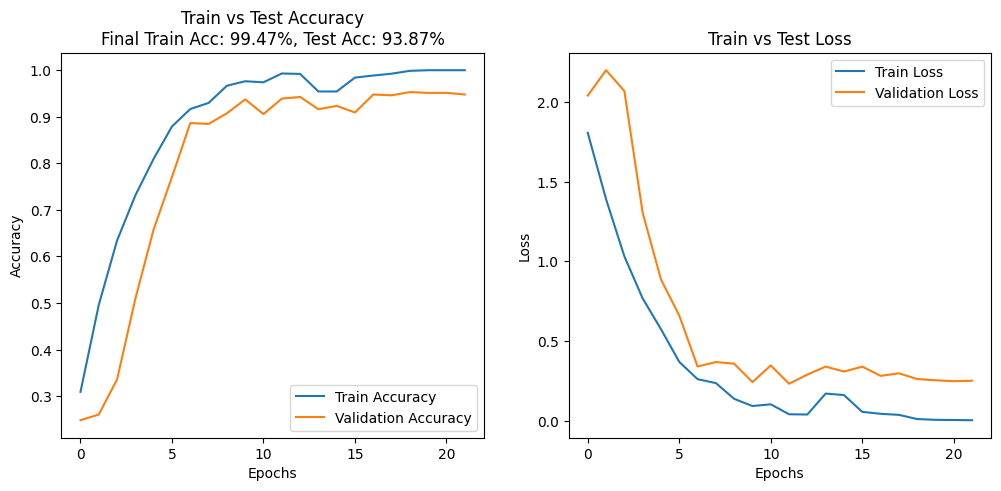

18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 149ms/step


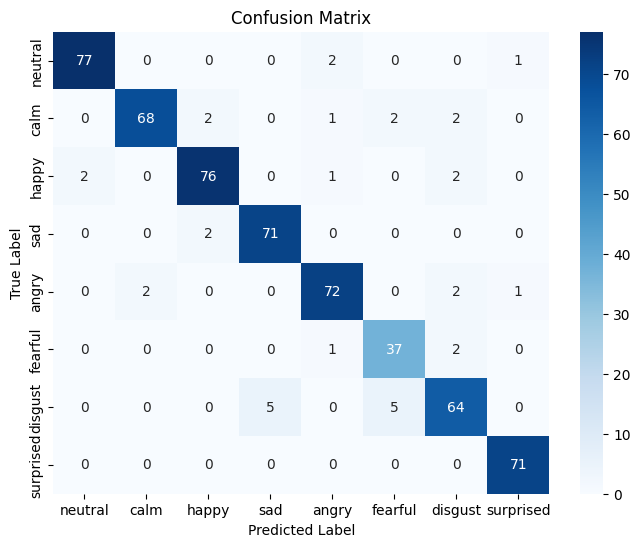

📊 Classification Report:
               precision    recall  f1-score   support

     neutral       0.97      0.96      0.97        80
        calm       0.97      0.91      0.94        75
       happy       0.95      0.94      0.94        81
         sad       0.93      0.97      0.95        73
       angry       0.94      0.94      0.94        77
     fearful       0.84      0.93      0.88        40
     disgust       0.89      0.86      0.88        74
   surprised       0.97      1.00      0.99        71

    accuracy                           0.94       571
   macro avg       0.93      0.94      0.94       571
weighted avg       0.94      0.94      0.94       571



In [ ]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report

# Dataset Path
dataset_path = "/content/drive/MyDrive/RAVDESS"

# Emotion Labels
emotions = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

# Feature Extraction Function
def extract_features(file_path):
    y, sr = librosa.load(file_path, duration=3, offset=0.5)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    return mfccs.T

# Load Dataset
data = []
labels = []
max_pad_length = 150

for subdir, _, files in os.walk(dataset_path):
    for file in files:
        if file.endswith('.wav'):
            file_path = os.path.join(subdir, file)
            emotion_code = file.split('-')[2]
            if emotion_code in emotions:
                try:
                    feature = extract_features(file_path)

                    # Padding
                    if feature.shape[0] < max_pad_length:
                        pad_width = max_pad_length - feature.shape[0]
                        feature = np.pad(feature, ((0, pad_width), (0, 0)), mode='constant')
                    else:
                        feature = feature[:max_pad_length, :]

                    data.append(feature)
                    labels.append(emotions[emotion_code])
                except Exception as e:
                    print(f"Error processing {file_path}: {e}")

# Convert to NumPy Arrays
data = np.array(data)
labels = np.array(labels)

# Encode Labels
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(labels)

# Split Data
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# Normalize Data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
X_test = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

# Reshape for CNN+LSTM
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

# Build CNN + LSTM Model
model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(max_pad_length, 40, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.TimeDistributed(layers.Flatten()),

    layers.LSTM(128, return_sequences=True),
    layers.LSTM(64),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(emotions), activation='softmax')
])

# Compile Model
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train Model and Store History
history = model.fit(X_train, y_train, epochs=50, batch_size=32,
                    validation_data=(X_test, y_test), callbacks=[early_stopping])

# Evaluate Model
test_loss, test_acc = model.evaluate(X_test, y_test)
train_loss, train_acc = model.evaluate(X_train, y_train)

# Print Final Accuracies
print(f"✅ Final Train Accuracy: {train_acc * 100:.2f}%")
print(f"✅ Final Test Accuracy: {test_acc * 100:.2f}%")

# Plot Accuracy & Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title(f'Train vs Test Accuracy\nFinal Train Acc: {train_acc * 100:.2f}%, Test Acc: {test_acc * 100:.2f}%')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Train vs Test Loss')

plt.show()

# Confusion Matrix & Classification Report
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_classes)
labels_sorted = [emotions[key] for key in sorted(emotions.keys())]

plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=labels_sorted, yticklabels=labels_sorted)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("📊 Classification Report:\n", classification_report(y_test, y_pred_classes, target_names=labels_sorted))

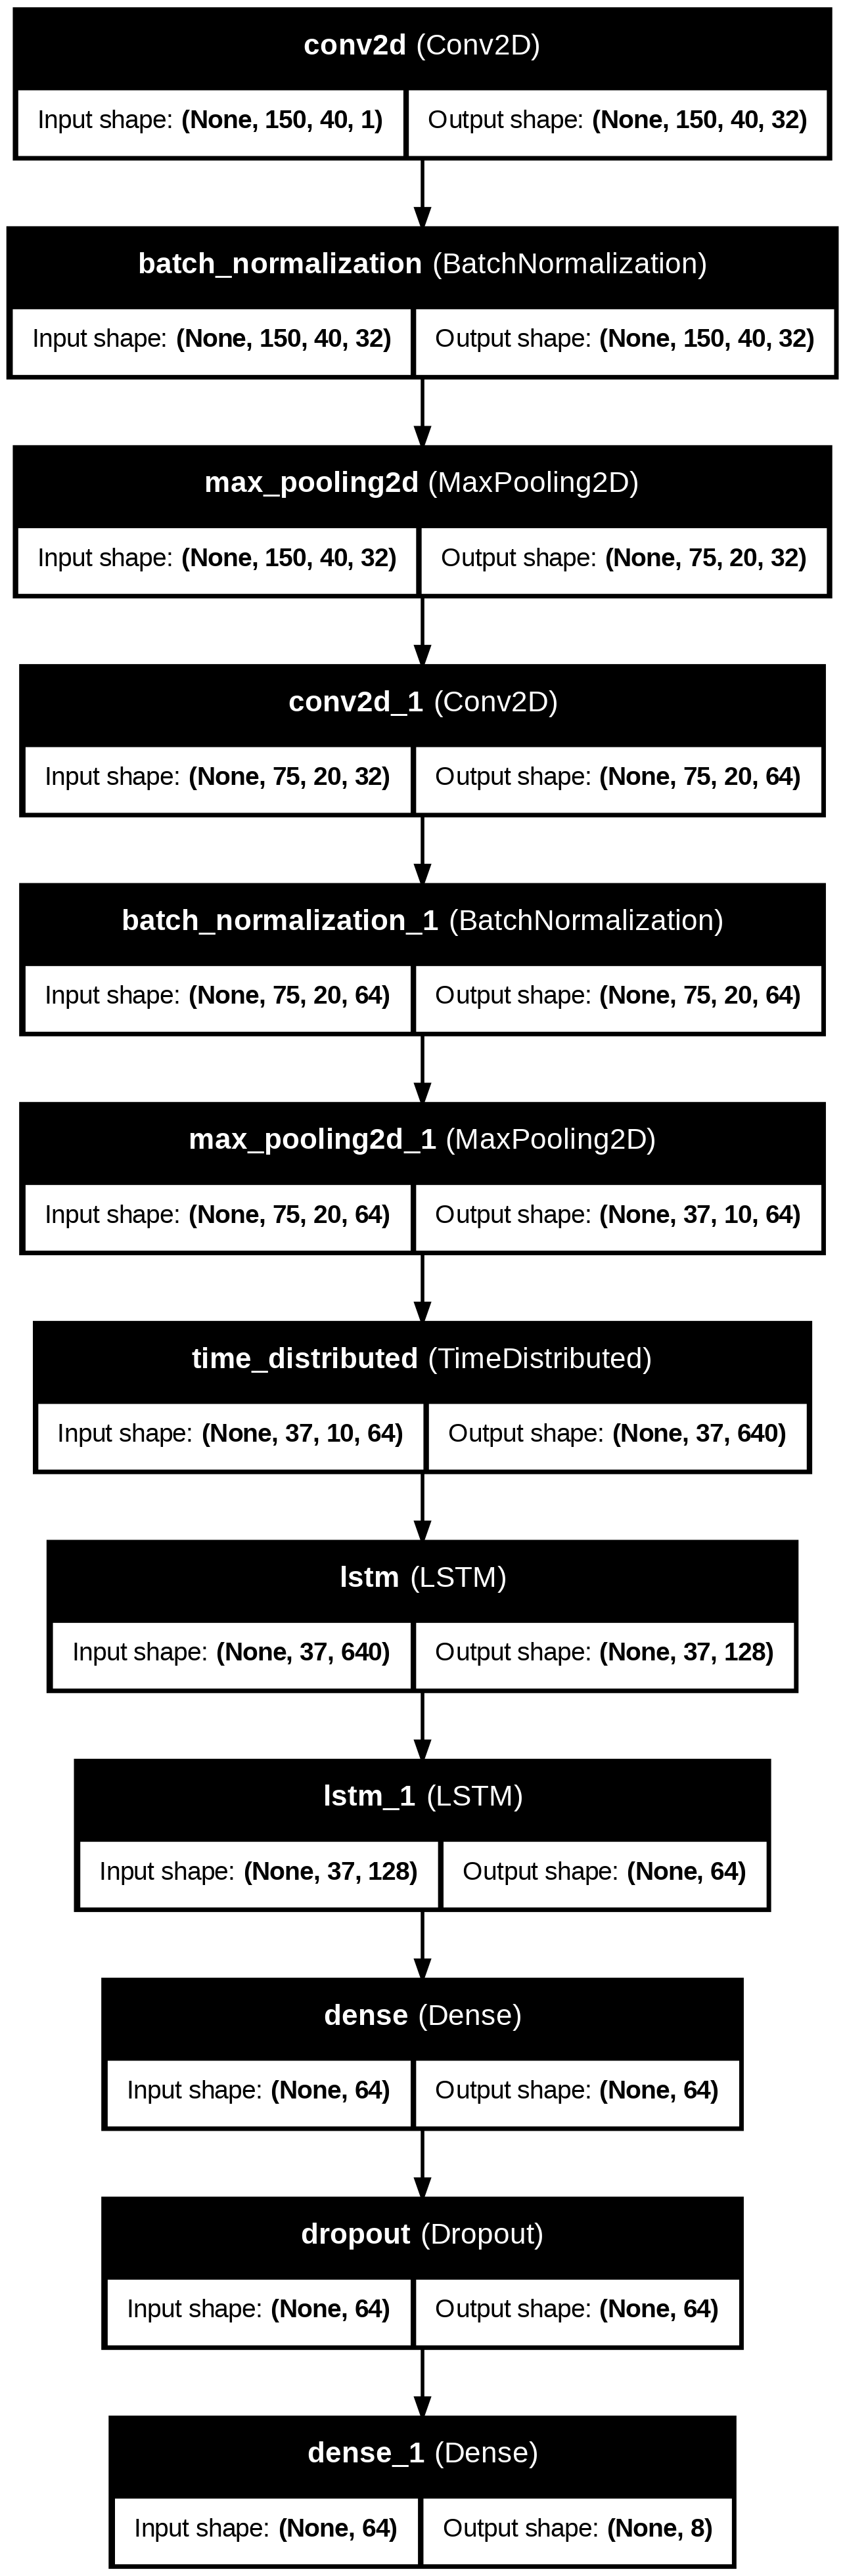

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(model, to_file='cnn_lstm_model_architecture.png', show_shapes=True, show_layer_names=True)


CNN+GRU


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 46s 280ms/step - accuracy: 0.1468 - loss: 2.0597 - val_accuracy: 0.2242 - val_loss: 1.9370
Epoch 2/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 38s 263ms/step - accuracy: 0.2746 - loss: 1.8598 - val_accuracy: 0.3853 - val_loss: 1.5991
Epoch 3/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 41s 263ms/step - accuracy: 0.4186 - loss: 1.5227 - val_accuracy: 0.5271 - val_loss: 1.2870
Epoch 4/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 40s 282ms/step - accuracy: 0.5148 - loss: 1.2780 - val_accuracy: 0.5884 - val_loss: 1.1085
Epoch 5/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 39s 274ms/step - accuracy: 0.6114 - loss: 1.0585 - val_accuracy: 0.6602 - val_loss: 0.9385
Epoch 6/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 38s 265ms/step - accuracy: 0.6917 - loss: 0.8449 - val_accuracy: 0.7373 - val_loss: 0.8067
Epoch 7/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 40s 278ms/step - accuracy: 0.7878 - loss: 0.6202 - val_accuracy: 0.6900 - val_loss: 0.8307
Epoch 8/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 38s 268ms/step - accuracy: 0.8101 - loss: 0

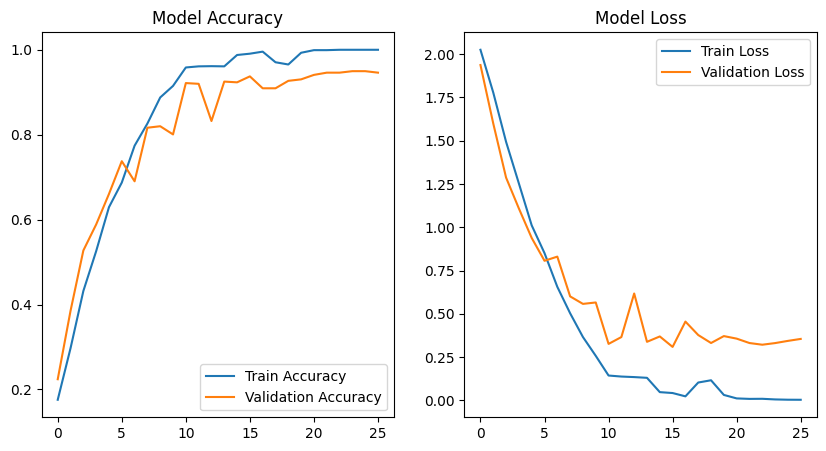

18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 166ms/step


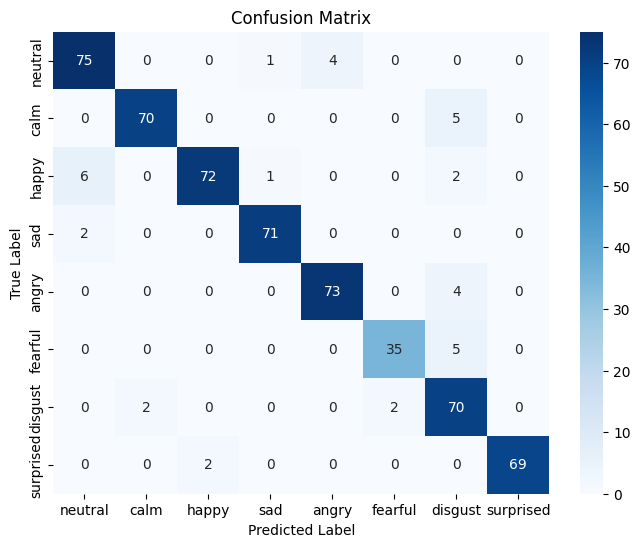

Classification Report:
               precision    recall  f1-score   support

     neutral       0.90      0.94      0.92        80
        calm       0.97      0.93      0.95        75
       happy       0.97      0.89      0.93        81
         sad       0.97      0.97      0.97        73
       angry       0.95      0.95      0.95        77
     fearful       0.95      0.88      0.91        40
     disgust       0.81      0.95      0.88        74
   surprised       1.00      0.97      0.99        71

    accuracy                           0.94       571
   macro avg       0.94      0.93      0.94       571
weighted avg       0.94      0.94      0.94       571



In [ ]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.callbacks import EarlyStopping

# 🔹 Dataset Path (Modify as needed)
dataset_path = "/content/drive/MyDrive/RAVDESS"

# 🔹 Emotion Labels
emotions = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

# 🔹 Function to Extract MFCC Features
def extract_features(file_path):
    try:
        y, sr = librosa.load(file_path, duration=3, offset=0.5)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        return mfccs.T  # Transpose to (time_steps, features)
    except Exception as e:
        print(f"⚠️ Skipping file {file_path}: {e}")
        return None  # Skip corrupt files

# 🔹 Load Dataset
data = []
labels = []
max_pad_length = 150  # Standardizing the input length

for subdir, _, files in os.walk(dataset_path):
    for file in files:
        if file.endswith('.wav'):
            file_path = os.path.join(subdir, file)
            emotion_code = file.split('-')[2]
            if emotion_code in emotions:
                feature = extract_features(file_path)
                if feature is not None:
                    # Padding to ensure consistent input size
                    if feature.shape[0] < max_pad_length:
                        pad_width = max_pad_length - feature.shape[0]
                        feature = np.pad(feature, ((0, pad_width), (0, 0)), mode='constant')
                    else:
                        feature = feature[:max_pad_length, :]

                    data.append(feature)
                    labels.append(emotions[emotion_code])

# 🔹 Convert to NumPy Arrays
data = np.array(data)
labels = np.array(labels)

# 🔹 Encode Labels
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(labels)

# 🔹 Split Data
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# 🔹 Normalize Data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
X_test = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

# 🔹 Reshape for CNN+GRU (Add Channel Dimension)
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

# 🔹 Build CNN + GRU Model
model = keras.Sequential([
    # CNN Layers for Feature Extraction
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(max_pad_length, 40, 1)),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Flatten CNN Output and Keep Temporal Structure
    layers.TimeDistributed(layers.Flatten()),

    # GRU Layers for Temporal Processing
    layers.GRU(128, return_sequences=True),
    layers.GRU(64),

    # Dense Layers
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(emotions), activation='softmax')
])

# 🔹 Compile Model
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 🔹 Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 🔹 Train Model
history = model.fit(X_train, y_train, epochs=50, batch_size=16,
                    validation_data=(X_test, y_test), callbacks=[early_stopping])

# 🔹 Evaluate Model
train_loss, train_acc = model.evaluate(X_train, y_train)
test_loss, test_acc = model.evaluate(X_test, y_test)

print(f"✅ Train Accuracy: {train_acc * 100:.2f}%")
print(f"✅ Test Accuracy: {test_acc * 100:.2f}%")

# 🔹 Plot Accuracy & Loss
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')

plt.show()

# 🔹 Confusion Matrix & Classification Report
from sklearn.metrics import confusion_matrix, classification_report

# Predict on test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=emotions.values(), yticklabels=emotions.values())
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print("Classification Report:\n", classification_report(y_test, y_pred_classes, target_names=emotions.values()))


CNN+LSTM (GRADIO)

In [ ]:
import os
import numpy as np
import librosa
import librosa.display
import gradio as gr
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report

# Dataset Path
dataset_path = "/content/drive/MyDrive/RAVDESS"

# Emotion Labels
emotions = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

# Feature Extraction Function
def extract_features(file_path, max_pad_length=150):
    y, sr = librosa.load(file_path, duration=3, offset=0.5)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

    if mfccs.shape[1] < max_pad_length:
        pad_width = max_pad_length - mfccs.shape[1]
        mfccs = np.pad(mfccs, ((0, 0), (0, pad_width)), mode='constant')
    else:
        mfccs = mfccs[:, :max_pad_length]

    return np.expand_dims(mfccs.T, axis=-1)

# Load Dataset
data = []
labels = []
max_pad_length = 150

for subdir, _, files in os.walk(dataset_path):
    for file in files:
        if file.endswith('.wav'):
            file_path = os.path.join(subdir, file)
            emotion_code = file.split('-')[2]
            if emotion_code in emotions:
                try:
                    feature = extract_features(file_path)

                    # Padding
                    if feature.shape[0] < max_pad_length:
                        pad_width = max_pad_length - feature.shape[0]
                        feature = np.pad(feature, ((0, pad_width), (0, 0)), mode='constant')
                    else:
                        feature = feature[:max_pad_length, :]

                    data.append(feature)
                    labels.append(emotions[emotion_code])
                except Exception as e:
                    print(f"Error processing {file_path}: {e}")

# Convert to NumPy Arrays
data = np.array(data)
labels = np.array(labels)

# Encode Labels
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(labels)

# Split Data
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# Normalize Data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
X_test = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

# Reshape for CNN+LSTM
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

# Build CNN + LSTM Model
model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(max_pad_length, 40, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.TimeDistributed(layers.Flatten()),

    layers.LSTM(128, return_sequences=True),
    layers.LSTM(64),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(emotions), activation='softmax')
])

# Compile Model
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train Model and Store History
history = model.fit(X_train, y_train, epochs=50, batch_size=32,
                    validation_data=(X_test, y_test), callbacks=[early_stopping])

# Save Model
model.save("/content/drive/MyDrive/saved_model.h5")

# Load Trained Model
model = keras.models.load_model("/content/drive/MyDrive/saved_model.h5")

# Prediction Function for Gradio
def predict_emotion(audio_file):
    features = extract_features(audio_file)
    features = np.expand_dims(features, axis=0)  # Add batch dimension

    predictions = model.predict(features)[0]  # Get probabilities
    predicted_index = np.argmax(predictions)

    # Get individual emotion
    predicted_emotion = label_encoder.inverse_transform([predicted_index])[0]

    # Get top 2 emotions if they have close probabilities
    sorted_indices = np.argsort(predictions)[::-1]  # Sort in descending order
    top_emotions = [(label_encoder.inverse_transform([idx])[0], predictions[idx]) for idx in sorted_indices[:2]]

    # If the top 2 emotions have close probabilities, return a combined label
    if abs(top_emotions[0][1] - top_emotions[1][1]) < 0.1:
        return f"Combination: {top_emotions[0][0]} + {top_emotions[1][0]}"

    return f"Emotion: {predicted_emotion}"

# Gradio Interface
interface = gr.Interface(
    fn=predict_emotion,
    inputs=gr.Audio(type="filepath"),
    outputs="text",
    title="Speech Emotion Recognition",
    description="Upload an audio file (wav format) to predict the emotion. If two emotions have close probabilities, a combination will be displayed."
)

# Launch Gradio app
interface.launch()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 55s 664ms/step - accuracy: 0.2071 - loss: 1.9914 - val_accuracy: 0.1278 - val_loss: 2.2255
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 46s 646ms/step - accuracy: 0.3556 - loss: 1.6813 - val_accuracy: 0.1278 - val_loss: 2.5433
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 82s 642ms/step - accuracy: 0.4869 - loss: 1.4129 - val_accuracy: 0.1278 - val_loss: 2.8433
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 46s 641ms/step - accuracy: 0.5809 - loss: 1.1858 - val_accuracy: 0.1278 - val_loss: 3.0668
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 84s 665ms/step - accuracy: 0.6519 - loss: 1.0010 - val_accuracy: 0.1734 - val_loss: 3.1171
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 80s 644ms/step - accuracy: 0.6896 - loss: 0.8971 - val_accuracy: 0.3030 - val_loss: 2.6820
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 47s 655ms/step - accuracy: 0.7706 - loss: 0.6919 - val_accuracy: 0.5044 - val_loss: 1.5490
Epoch 8/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 81s 637ms/step - accuracy: 0.8285 - loss: 0.5513 - val_accu

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://af2755da3f7e02106c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


CNN+GRU(GRadio)

In [ ]:
import os
import numpy as np
import librosa
import gradio as gr
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 Emotion Labels
emotions = {
    '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
    '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
}

# 🔹 Dataset Path
dataset_path = "/content/drive/MyDrive/RAVDESS"

# 🔹 Feature Extraction Function
def extract_features(file_path):
    try:
        y, sr = librosa.load(file_path, duration=3, offset=0.5)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        return mfccs.T
    except Exception as e:
        return None

# 🔹 Load Dataset
data, labels = [], []
max_pad_length = 150

for subdir, _, files in os.walk(dataset_path):
    for file in files:
        if file.endswith('.wav'):
            file_path = os.path.join(subdir, file)
            emotion_code = file.split('-')[2]
            if emotion_code in emotions:
                feature = extract_features(file_path)
                if feature is not None:
                    if feature.shape[0] < max_pad_length:
                        pad_width = max_pad_length - feature.shape[0]
                        feature = np.pad(feature, ((0, pad_width), (0, 0)), mode='constant')
                    else:
                        feature = feature[:max_pad_length, :]
                    data.append(feature)
                    labels.append(emotions[emotion_code])

# 🔹 Convert to NumPy Arrays
data = np.array(data)
labels = np.array(labels)

# 🔹 Encode Labels
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(labels)

# 🔹 Split Data
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# 🔹 Normalize Data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
X_test = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

# 🔹 Reshape for CNN-GRU
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

# 🔹 Build CNN + GRU Model
model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(max_pad_length, 40, 1)),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.TimeDistributed(layers.Flatten()),
    layers.GRU(128, return_sequences=True),
    layers.GRU(64),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(emotions), activation='softmax')
])

# 🔹 Compile Model
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 🔹 Train Model
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))

# 🔹 Save Model
model.save("ser_model.h5")

# 🔹 Load Model for Gradio
model = keras.models.load_model("ser_model.h5")

# 🔹 Prediction Function for Gradio
def predict_emotion(audio_file):
    features = extract_features(audio_file)
    if features is None:
        return "Error: Could not process audio file."

    # Standardizing and reshaping
    features = scaler.transform(features)  # Normalize
    features = np.expand_dims(features, axis=-1)  # Add channel dimension
    features = np.array([features])  # Convert to batch format

    # Predict emotion
    prediction = model.predict(features)
    predicted_class = np.argmax(prediction)

    return f"Predicted Emotion: {emotions[predicted_class]}"

# 🔹 Gradio UI
iface = gr.Interface(
    fn=predict_emotion,
    inputs=gr.Audio(type="filepath"),
    outputs="text",
    title="Speech Emotion Recognition",
    description="Upload an audio file to detect the emotion in the speaker's voice."
)

# 🔹 Run Gradio
iface.launch(share=True)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 47s 281ms/step - accuracy: 0.1580 - loss: 2.0474 - val_accuracy: 0.2294 - val_loss: 1.9079
Epoch 2/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 39s 275ms/step - accuracy: 0.2975 - loss: 1.8296 - val_accuracy: 0.4168 - val_loss: 1.4578
Epoch 3/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 41s 277ms/step - accuracy: 0.4215 - loss: 1.4571 - val_accuracy: 0.5604 - val_loss: 1.2015
Epoch 4/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 43s 292ms/step - accuracy: 0.5426 - loss: 1.2204 - val_accuracy: 0.5377 - val_loss: 1.2112
Epoch 5/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 38s 263ms/step - accuracy: 0.6152 - loss: 1.0513 - val_accuracy: 0.7180 - val_loss: 0.8304
Epoch 6/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 42s 269ms/step - accuracy: 0.6928 - loss: 0.8330 - val_accuracy: 0.7303 - val_loss: 0.8109
Epoch 7/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 41s 271ms/step - accuracy: 0.7587 - loss: 0.6897 - val_accuracy: 0.7863 - val_loss: 0.6895
Epoch 8/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 40s 277ms/step - accuracy: 0.8417 - loss: 0

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c1b2d76266b2eac907.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


train_model

Upgrading CNN+LSTM(GRadiio)

In [ ]:
import os
import numpy as np
import librosa
import librosa.display
import gradio as gr
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE  # For handling class imbalance
import keras_tuner as kt  # For hyperparameter tuning

# Dataset Path
dataset_path = "/content/drive/MyDrive/RAVDESS"

# Emotion Labels
emotions = {
    '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
    '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
}

# Feature Extraction Function
def extract_features(file_path, max_pad_length=150):
    y, sr = librosa.load(file_path, duration=3, offset=0.5)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    delta = librosa.feature.delta(mfccs)
    delta_delta = librosa.feature.delta(mfccs, order=2)

    combined_features = np.vstack((mfccs, delta, delta_delta))

    # Handle variable-length audio
    combined_features = librosa.util.fix_length(combined_features, size=max_pad_length, axis=1)
    return np.expand_dims(combined_features.T, axis=-1)

# Load Dataset
data, labels = [], []
for subdir, _, files in os.walk(dataset_path):
    for file in files:
        if file.endswith('.wav'):
            file_path = os.path.join(subdir, file)
            emotion_code = file.split('-')[2]
            if emotion_code in emotions:
                try:
                    feature = extract_features(file_path)
                    data.append(feature)
                    labels.append(emotions[emotion_code])
                except Exception as e:
                    print(f"Error processing {file_path}: {e}")

# Convert to NumPy Arrays
data = np.array(data)
labels = np.array(labels)

# Encode Labels
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(labels)

# Split Data
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# Normalize Data (Using MinMaxScaler instead of StandardScaler)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
X_test = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

# Handle Class Imbalance using SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train.reshape(X_train.shape[0], -1), y_train)
X_train_resampled = X_train_resampled.reshape(-1, X_train.shape[1], X_train.shape[2], X_train.shape[3])

# Reshape for CNN+LSTM
X_train_resampled = np.expand_dims(X_train_resampled, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

# Hyperparameter Tuning Function
def build_model(hp):
    model = keras.Sequential([
        layers.Conv2D(hp.Int('conv1_units', 32, 64, step=16), kernel_size=(3, 3), activation='relu', padding='same', input_shape=(150, 120, 1)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(hp.Int('conv2_units', 64, 128, step=16), kernel_size=(3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.TimeDistributed(layers.Flatten()),
        layers.LSTM(hp.Int('lstm1_units', 64, 128, step=32), return_sequences=True),
        layers.LSTM(hp.Int('lstm2_units', 32, 64, step=16)),

        layers.Dense(hp.Int('dense_units', 32, 128, step=32), activation='relu'),
        layers.Dropout(hp.Float('dropout', 0.2, 0.5, step=0.1)),
        layers.Dense(len(emotions), activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp.Choice('learning_rate', [0.001, 0.0005, 0.0001])),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Hyperparameter Search
tuner = kt.Hyperband(build_model, objective='val_accuracy', max_epochs=30, factor=3, directory='tuning', project_name='SER')
tuner.search(X_train_resampled, y_train_resampled, epochs=30, validation_data=(X_test, y_test), callbacks=[EarlyStopping(monitor='val_loss', patience=5)])

# Get Best Model
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.hypermodel.build(best_hps)

# Train Final Model
history = best_model.fit(X_train_resampled, y_train_resampled, epochs=50, batch_size=32, validation_data=(X_test, y_test), callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)])

# Save Model
best_model.save("/content/drive/MyDrive/saved_model.h5")

# Load Model
model = keras.models.load_model("/content/drive/MyDrive/saved_model.h5")

# Evaluate Model
predictions = model.predict(X_test)
y_pred = np.argmax(predictions, axis=1)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Confusion Matrix
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Gradio Interface
def predict_emotion(audio_file):
    features = extract_features(audio_file)
    features = np.expand_dims(features, axis=0)
    predictions = model.predict(features)[0]
    predicted_index = np.argmax(predictions)
    return f"Emotion: {label_encoder.inverse_transform([predicted_index])[0]}"

interface = gr.Interface(fn=predict_emotion, inputs=gr.Audio(type="filepath"), outputs="text", title="Speech Emotion Recognition", description="Upload an audio file (wav format) to predict the emotion.")
interface.launch()


Trial 8 Complete [00h 06m 47s]
val_accuracy: 0.141856387257576

Best val_accuracy So Far: 0.141856387257576
Total elapsed time: 01h 08m 25s

Search: Running Trial #9

Value             |Best Value So Far |Hyperparameter
64                |48                |conv1_units
64                |128               |conv2_units
128               |96                |lstm1_units
32                |48                |lstm2_units
96                |96                |dense_units
0.3               |0.2               |dropout
0.0001            |0.0001            |learning_rate
2                 |2                 |tuner/epochs
0                 |0                 |tuner/initial_epoch
3                 |3                 |tuner/bracket
0                 |0                 |tuner/round

Epoch 1/2
77/78 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.1669 - loss: 2.0526

KeyboardInterrupt: 